# Evaluación 1 — Calidad y Preparación de Datos
## Rendimiento académico estudiantil

**Dataset:** `rendimiento_academico_evaluacion.csv`

Este notebook desarrolla el proceso completo solicitado en la pauta de la Evaluación 1:

1. Diagnóstico de calidad de datos
2. Análisis exploratorio de datos (EDA) y preguntas de investigación
3. Tratamiento de los datos (justificado a partir del diagnóstico)
4. Implementación mediante `Pipeline` / `ColumnTransformer` de scikit-learn
5. Generación del dataset final tratado (`rendimiento_academico_limpio.csv`) y comparación original vs. tratado

## 0. Importación de librerías

In [1]:
import os
import unicodedata
import warnings

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 0. Carga del set de datos

Se descarga el archivo directamente desde el repositorio del equipo usando `wget`.
Si el archivo ya existe localmente (por ejemplo, al re-ejecutar el notebook), se omite
la descarga y se utiliza la copia local, de manera que el notebook sea reproducible de
principio a fin sin depender de la conexión a internet.

> **Nota para el equipo:** reemplazar `DATA_URL` por el enlace *raw* del archivo
> `rendimiento_academico_evaluacion.csv` dentro de la carpeta `E1 - EDA` del repositorio
> del grupo antes de la entrega final.

In [18]:
DATA_URL = "https://raw.githubusercontent.com/sebastianip3/EV-IA/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv"
DATA_FILE = "rendimiento_academico_evaluacion.csv"

if not os.path.exists(DATA_FILE):
    exit_code = os.system(f"wget -q -O {DATA_FILE} '{DATA_URL}'")
    if exit_code != 0 or not os.path.exists(DATA_FILE) or os.path.getsize(DATA_FILE) == 0:
        raise FileNotFoundError(
            "No fue posible descargar el archivo con wget. "
            "Verifique la URL del repositorio o coloque el CSV en el directorio de trabajo."
        )

df_raw = pd.read_csv(DATA_FILE)
print(f"Registros cargados: {df_raw.shape[0]}  |  Variables: {df_raw.shape[1]}")
df_raw.head()

Registros cargados: 5100  |  Variables: 11


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


## 1. Diagnóstico de calidad de datos

### 1.1 Caracterización del dataset

In [6]:
n_registros, n_variables = df_raw.shape
print(f"Cantidad de registros : {n_registros}")
print(f"Cantidad de variables : {n_variables}")
print()
print("Tipos de datos por columna:")
print(df_raw.dtypes)

Cantidad de registros : 5100
Cantidad de variables : 11

Tipos de datos por columna:
StudentID                   str
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship                 str
Program                     str
FinalGrade              float64
dtype: object


In [7]:
id_var = "StudentID"
target_var = "FinalGrade"
categorical_vars = (df_raw.select_dtypes(include=["object", "string", "category"])
                    .columns.tolist())
categorical_vars = [c for c in categorical_vars if c != id_var]
numeric_vars = [c for c in df_raw.columns
                if pd.api.types.is_numeric_dtype(df_raw[c]) and c != target_var]

resumen_caracterizacion = pd.DataFrame({
    "Tipo": ["Identificador", "Numérica (feature)", "Categórica (feature)", "Target"],
    "Variables": [
        id_var,
        ", ".join(numeric_vars),
        ", ".join(categorical_vars),
        target_var,
    ],
    "Cantidad": [1, len(numeric_vars), len(categorical_vars), 1],
})
resumen_caracterizacion

,Tipo,Variables,Cantidad
0,Identificador,StudentID,1
1,Numérica (feature),"Age, StudyHours, Attendance, PreviousGPA, Assi...",7
2,Categórica (feature),"Scholarship, Program",2
3,Target,FinalGrade,1


**Interpretación:** el dataset contiene **5.100 registros** y **11 variables**. `StudentID`
actúa como identificador único de cada estudiante, `FinalGrade` es la variable objetivo
(calificación final, escala 1–10), y el resto son *features* de tipo numérico
(`Age`, `StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`,
`InternetHours`) o categórico (`Scholarship`, `Program`).

### 1.2 Valores faltantes

In [8]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw) * 100).round(2)

reporte_faltantes = pd.DataFrame({
    "Valores faltantes": missing_count,
    "% faltante": missing_pct,
}).sort_values("% faltante", ascending=False)
reporte_faltantes = reporte_faltantes[reporte_faltantes["Valores faltantes"] > 0]
reporte_faltantes

,Valores faltantes,% faltante
Attendance,224,4.39
AssignmentsCompleted,216,4.24
StudyHours,181,3.55
InternetHours,176,3.45
PreviousGPA,162,3.18
SleepHours,122,2.39
Age,103,2.02
Scholarship,81,1.59
Program,70,1.37


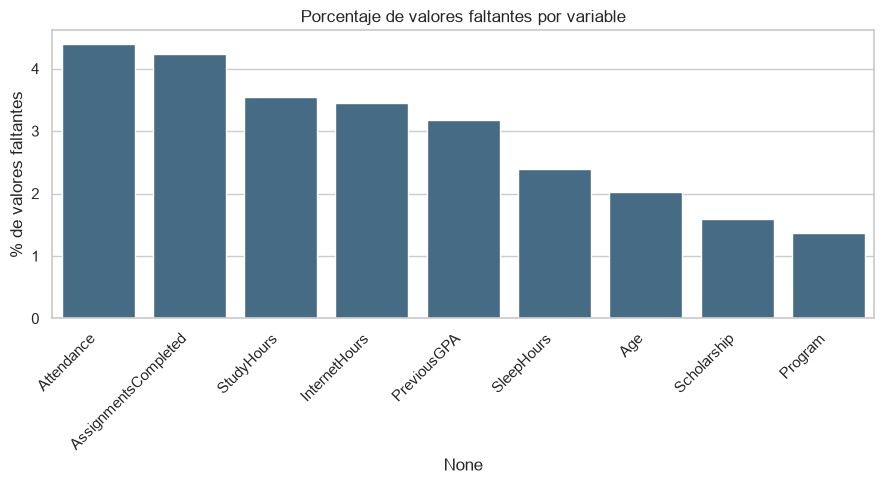

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(x=reporte_faltantes.index, y=reporte_faltantes["% faltante"], color="#3B6E8F")
plt.xticks(rotation=45, ha="right")
plt.ylabel("% de valores faltantes")
plt.title("Porcentaje de valores faltantes por variable")
plt.tight_layout()
plt.show()

**Hallazgos:** todas las *features* presentan valores faltantes, entre **1,4 % y 4,4 %** de
los registros. Las variables con mayor proporción de datos faltantes son `Attendance`
(4,39 %), `AssignmentsCompleted` (4,24 %) y `StudyHours` (3,55 %). La variable objetivo
`FinalGrade` no presenta valores nulos. Ninguna variable supera el 5 % de datos faltantes,
por lo que **no se justifica eliminar columnas completas**; el mecanismo más plausible es de
tipo MCAR/MAR (errores dispersos de registro), por lo que se optará por **imputación**
(mediana para numéricas, moda para categóricas) dentro del pipeline, en lugar de eliminar
filas y perder información.

### 1.3 Registros duplicados

In [10]:
dup_full = df_raw.duplicated().sum()
dup_by_id = df_raw.duplicated(subset=["StudentID"]).sum()

print(f"Registros totalmente duplicados (todas las columnas): {dup_full} "
      f"({dup_full/len(df_raw)*100:.2f}% del dataset)")
print(f"Registros duplicados según 'StudentID'              : {dup_by_id} "
      f"({dup_by_id/len(df_raw)*100:.2f}% del dataset)")

df_raw[df_raw.duplicated(subset=["StudentID"], keep=False)].sort_values("StudentID").head(6)

Registros totalmente duplicados (todas las columnas): 100 (1.96% del dataset)
Registros duplicados según 'StudentID'              : 100 (1.96% del dataset)


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
5017,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
4895,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
1437,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
3572,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
736,STU-10043,22.0,2.34,78.24,4.75,35.87,7.79,2.44,No,Administración,1.78
4829,STU-10043,22.0,2.34,78.24,4.75,35.87,7.79,2.44,No,Administración,1.78


**Decisión:** `StudentID` es la variable natural para identificar de forma unívoca a un
estudiante. Los **100 registros duplicados coinciden exactamente en `StudentID` y en el
resto de las columnas**, por lo que corresponden a la misma observación repetida (p. ej.
por un doble envío o un error de concatenación de archivos) y no aportan información nueva.
**Se eliminarán conservando la primera ocurrencia** (`drop_duplicates(keep="first")`), ya que
mantenerlos sesgaría las estadísticas descriptivas y el entrenamiento de cualquier modelo
posterior al ponderar más esas observaciones.

### 1.4 Inconsistencias

In [11]:
print("Valores únicos de 'Scholarship':")
print(df_raw["Scholarship"].value_counts(dropna=False))
print()
print("Valores únicos de 'Program':")
print(df_raw["Program"].value_counts(dropna=False))

Valores únicos de 'Scholarship':
Scholarship
No     3364
Sí     1620
NaN      81
si       10
No       10
NO        8
SÍ        5
SI        2
Name: count, dtype: int64

Valores únicos de 'Program':
Program
Ingeniería Informática     1424
Ingeniería Industrial      1119
Ingeniería Civil           1004
Administración              787
Contador Auditor            660
NaN                          70
Ingenieria Informatica       10
INGENIERÍA INFORMÁTICA        7
Ingeniería Civil              5
Ingeniería informática        4
INGENIERÍA CIVIL              4
ADMINISTRACIÓN                3
Administracion                3
Name: count, dtype: int64


In [12]:
inconsistencias = []

n_scholarship_bad = int(df_raw["Scholarship"].isin(["SÍ ", "si", "SI", "No ", "NO"]).sum())
inconsistencias.append({
    "Variable": "Scholarship",
    "Problema": "Categorías equivalentes escritas de forma distinta "
                "('Sí'/'SÍ '/'si'/'SI' y 'No'/'No '/'NO')",
    "Cantidad de registros afectados": n_scholarship_bad,
})

programas_validos = ["Ingeniería Industrial", "Ingeniería Informática", "Ingeniería Civil",
                      "Administración", "Contador Auditor"]
n_program_bad = int((df_raw["Program"].notna() & ~df_raw["Program"].isin(programas_validos)).sum())
inconsistencias.append({
    "Variable": "Program",
    "Problema": "Categorías equivalentes con distinta capitalización, tildes faltantes "
                "o espacios (p. ej. 'Ingenieria Informatica', 'INGENIERÍA CIVIL', "
                "'Administración ')",
    "Cantidad de registros afectados": n_program_bad,
})

inconsistencias.append({
    "Variable": "Attendance",
    "Problema": "Porcentaje de asistencia fuera del rango lógico [0, 100] "
                "(valores negativos y valores mayores a 100)",
    "Cantidad de registros afectados": int(((df_raw["Attendance"] < 0) | (df_raw["Attendance"] > 100)).sum()),
})

inconsistencias.append({
    "Variable": "SleepHours",
    "Problema": "Horas de sueño diarias negativas (imposible físicamente)",
    "Cantidad de registros afectados": int((df_raw["SleepHours"] < 0).sum()),
})

inconsistencias.append({
    "Variable": "InternetHours",
    "Problema": "Horas diarias de uso de Internet superiores a 24 h (imposible físicamente)",
    "Cantidad de registros afectados": int((df_raw["InternetHours"] > 24).sum()),
})

inconsistencias.append({
    "Variable": "FinalGrade",
    "Problema": "Calificación final fuera de la escala documentada [1, 10] "
                "(incluye valores negativos)",
    "Cantidad de registros afectados": int(((df_raw["FinalGrade"] < 1) | (df_raw["FinalGrade"] > 10)).sum()),
})

df_inconsistencias = pd.DataFrame(inconsistencias)
df_inconsistencias

,Variable,Problema,Cantidad de registros afectados
0,Scholarship,Categorías equivalentes escritas de forma dist...,35
1,Program,Categorías equivalentes con distinta capitaliz...,36
2,Attendance,Porcentaje de asistencia fuera del rango lógic...,20
3,SleepHours,Horas de sueño diarias negativas (imposible fí...,8
4,InternetHours,Horas diarias de uso de Internet superiores a ...,31
5,FinalGrade,Calificación final fuera de la escala document...,4


In [15]:
neg_att = df_raw.loc[df_raw["Attendance"] < 0, "Attendance"]
neg_sleep = df_raw.loc[df_raw["SleepHours"] < 0, "SleepHours"]
print("Estadística de los valores NEGATIVOS de Attendance (antes de corregir signo):")
print(neg_att.describe())
print("\nAl tomar valor absoluto quedan en rango [0,100]:", (neg_att.abs() <= 100).all())
print("\nEstadística de los valores NEGATIVOS de SleepHours (antes de corregir signo):")
print(neg_sleep.describe())
print("\nAl tomar valor absoluto quedan en rango [0,24]:", (neg_sleep.abs() <= 24).all())

Estadística de los valores NEGATIVOS de Attendance (antes de corregir signo):
count     8.000000
mean    -12.127003
std       7.420068
min     -19.961240
25%     -17.711635
50%     -13.779201
75%      -7.746252
max      -1.576211
Name: Attendance, dtype: float64

Al tomar valor absoluto quedan en rango [0,100]: True

Estadística de los valores NEGATIVOS de SleepHours (antes de corregir signo):
count    8.000000
mean    -4.960778
std      2.254557
min     -7.713498
25%     -6.469974
50%     -5.478183
75%     -3.937389
max     -1.391069
Name: SleepHours, dtype: float64

Al tomar valor absoluto quedan en rango [0,24]: True


**Estrategias de tratamiento propuestas** (se justifican y ejecutan en la sección 3):

| Variable | Problema | Estrategia propuesta |
|---|---|---|
| `Scholarship` | Variantes de texto para "Sí"/"No" | Normalizar (quitar espacios, mayúsculas/tildes) a `Sí` / `No` |
| `Program` | Variantes de texto de los mismos 5 programas | Normalizar a un catálogo canónico de 5 programas |
| `Attendance` | Valores < 0 y > 100 | Los negativos son coherentes en magnitud con un error de signo (su valor absoluto cae en [0,100]) → aplicar `abs()`. Los > 100 no tienen una corrección evidente → tratar como dato inválido (poner `NaN`) e imputar |
| `SleepHours` | Valores < 0 | Igual que `Attendance`: el valor absoluto cae en un rango fisiológicamente razonable (1–8 h) → aplicar `abs()` |
| `InternetHours` | Valores > 24 h/día | Físicamente imposible y sin corrección evidente (no es un simple error de signo o de escala consistente) → tratar como dato inválido (`NaN`) e imputar |
| `FinalGrade` (target) | Fuera de la escala [1,10] | Al ser la variable objetivo, no se imputa: se eliminan esas **4 filas** (0,08 % del dataset), pérdida de información mínima |

### 1.5 Valores atípicos (outliers)

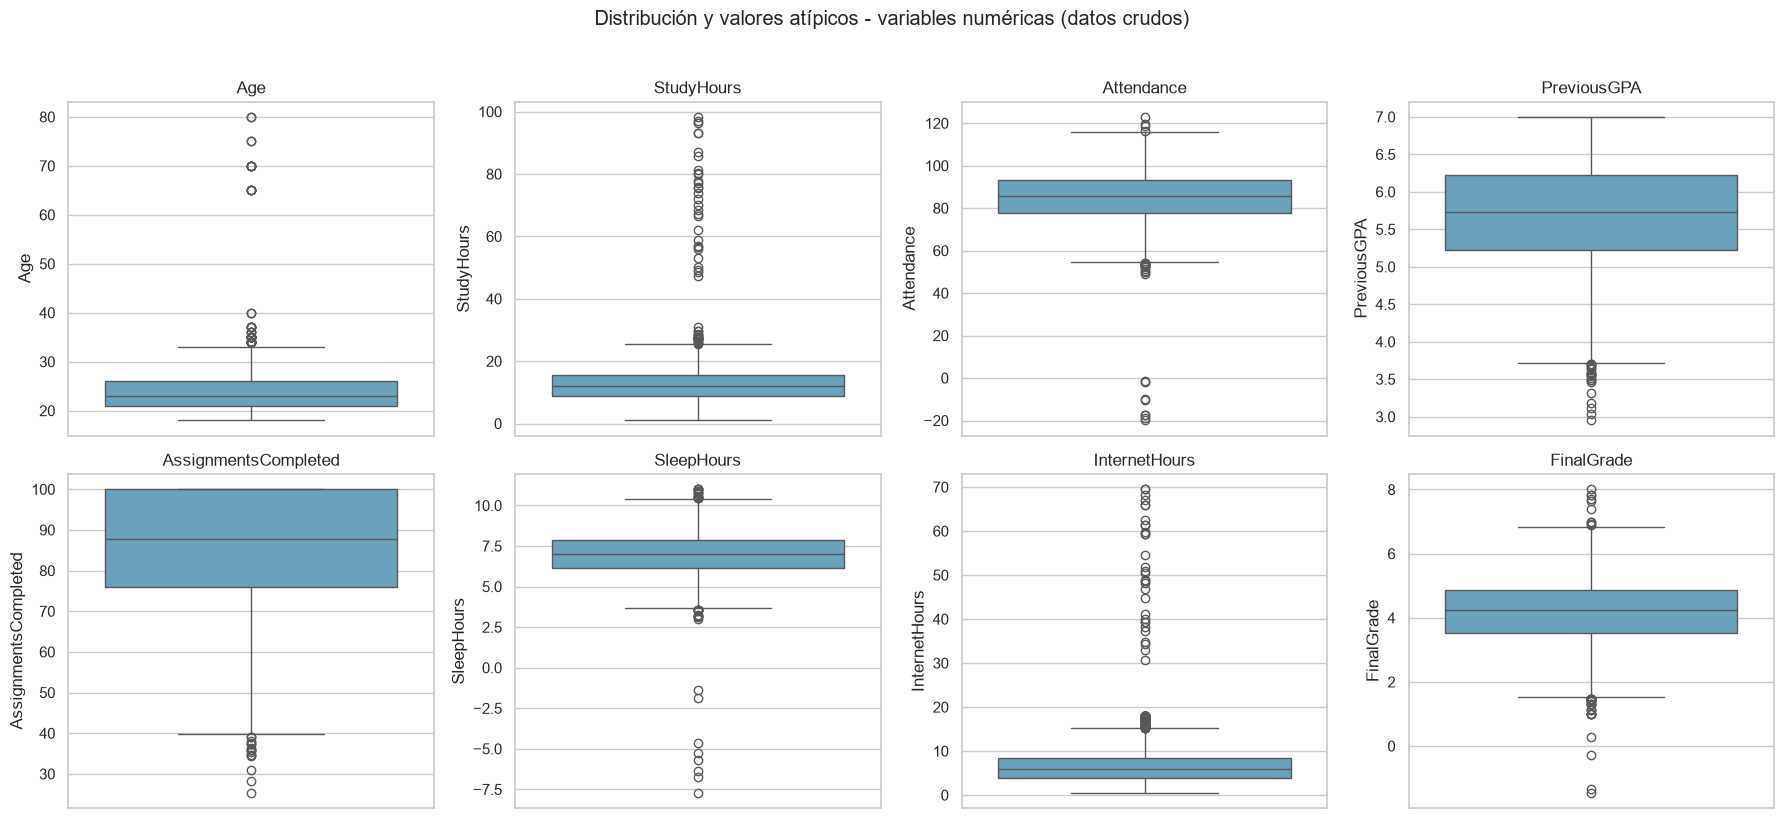

In [14]:
num_cols_outliers = ["Age", "StudyHours", "Attendance", "PreviousGPA",
                      "AssignmentsCompleted", "SleepHours", "InternetHours", "FinalGrade"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols_outliers):
    sns.boxplot(y=df_raw[col], ax=ax, color="#5DA5C9")
    ax.set_title(col)
plt.suptitle("Distribución y valores atípicos - variables numéricas (datos crudos)", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
def resumen_outliers_iqr(df, cols):
    filas = []
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[c] < lo) | (df[c] > hi)).sum()
        filas.append({
            "Variable": c, "Q1": round(q1, 2), "Q3": round(q3, 2),
            "Límite inferior (IQR)": round(lo, 2), "Límite superior (IQR)": round(hi, 2),
            "N° outliers": int(n_out), "% outliers": round(n_out / len(df) * 100, 2),
        })
    return pd.DataFrame(filas)

tabla_outliers = resumen_outliers_iqr(df_raw, num_cols_outliers)
tabla_outliers

,Variable,Q1,Q3,Límite inferior (IQR),Límite superior (IQR),N° outliers,% outliers
0,Age,21.00,26.00,13.50,33.50,63,1.24
1,StudyHours,8.75,15.44,-1.29,25.48,49,0.96
2,Attendance,77.58,93.01,54.43,116.16,27,0.53
3,PreviousGPA,5.22,6.23,3.70,7.75,21,0.41
4,AssignmentsCompleted,75.85,100.00,39.62,136.23,17,0.33
5,SleepHours,6.16,7.86,3.61,10.41,34,0.67
6,InternetHours,3.80,8.39,-3.09,15.28,145,2.84
7,FinalGrade,3.51,4.86,1.48,6.89,37,0.73


**Interpretación — outliers válidos (extremos) vs. inválidos:**

- **Valores fuera de dominio** (`Attendance` < 0 o > 100, `SleepHours` < 0,
  `InternetHours` > 24 h/día, `FinalGrade` fuera de [1,10]): ya fueron identificados como
  **inconsistencias de dominio (valores inválidos)** en la sección 1.4, y se corrigen o
  se marcan como faltantes en la sección 3 — no se tratan aquí como "outliers" a
  winsorizar, porque no son extremos estadísticos sino datos imposibles.
- **`Age` (outliers superiores, 35–80 años):** son estadísticamente atípicos según IQR,
  pero **no son imposibles ni inválidos**: puede haber estudiantes adultos que retoman
  estudios. Se decide **no winsorizar `Age`**: acotar la edad real de un estudiante (p. ej.
  convertir 65 años en el límite superior del IQR) alteraría un dato demográfico verídico
  sin una justificación de dominio sólida. Solo se imputan sus valores faltantes; el resto
  se deja intacto.
- **`StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`,
  `InternetHours` (una vez corregidos los valores inválidos de dominio):** los outliers
  restantes corresponden a la cola natural de la distribución (semanas de dedicación
  intensiva, asistencia o sueño anormalmente bajos/altos pero fisiológicamente posibles,
  buen/mal desempeño). A diferencia de `Age`, no son un atributo demográfico inmodificable
  sino mediciones de comportamiento, por lo que **sí se acotarán mediante capping IQR
  (winsorización)** dentro del pipeline, para estabilizar su influencia sin descartar la
  observación.
- **`FinalGrade` (target):** al ser la variable objetivo, sus valores extremos válidos
  (dentro de [1,10]) **no se tratan**: no corresponde transformar el target de la misma
  forma que las features, ya que introduciría un sesgo artificial en lo que se busca
  predecir. Esos ~30 valores extremos válidos permanecen en el dataset final tal cual.

## 2. Análisis exploratorio de datos (EDA)

Para el EDA se trabaja sobre una versión del dataset con las **correcciones básicas de
calidad ya aplicadas** (duplicados eliminados, signos corregidos, categorías
normalizadas, valores inválidos marcados como `NaN`), de forma que los gráficos y
estadísticas no estén distorsionados por errores de captura. La imputación final y el
armado del pipeline se realizan en la sección 3.

In [20]:
def normaliza_texto(serie):
    def _norm(x):
        if pd.isna(x):
            return x
        x = str(x).strip()
        x = "".join(
            c for c in unicodedata.normalize("NFKD", x)
            if not unicodedata.combining(c)
        )
        return x.lower()
    return serie.apply(_norm)

df_eda = df_raw.copy()

# 1) Duplicados
df_eda = df_eda.drop_duplicates(keep="first").reset_index(drop=True)

# 2) Normalizacion de categoricas
scholarship_map = {"si": "Sí", "no": "No"}
df_eda["Scholarship"] = normaliza_texto(df_eda["Scholarship"]).map(scholarship_map)

program_map = {
    "ingenieria industrial": "Ingeniería Industrial",
    "ingenieria informatica": "Ingeniería Informática",
    "ingenieria civil": "Ingeniería Civil",
    "administracion": "Administración",
    "contador auditor": "Contador Auditor",
}
df_eda["Program"] = normaliza_texto(df_eda["Program"]).map(program_map)

# 3) Correccion de errores de signo
df_eda["Attendance"] = df_eda["Attendance"].apply(lambda x: abs(x) if pd.notna(x) else x)
df_eda["SleepHours"] = df_eda["SleepHours"].apply(lambda x: abs(x) if pd.notna(x) else x)

# 4) Valores fuera de dominio -> NaN (se imputan mas adelante en el pipeline)
df_eda.loc[df_eda["Attendance"] > 100, "Attendance"] = np.nan
df_eda.loc[df_eda["InternetHours"] > 24, "InternetHours"] = np.nan

# 5) Target fuera de escala -> se elimina la fila (no se imputa el target)
df_eda = df_eda[df_eda["FinalGrade"].between(1, 10)].reset_index(drop=True)

print(f"Filas tras limpieza básica para EDA: {df_eda.shape[0]}")
df_eda.head()

Filas tras limpieza básica para EDA: 4996


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


### 2.1 Distribución de las variables numéricas

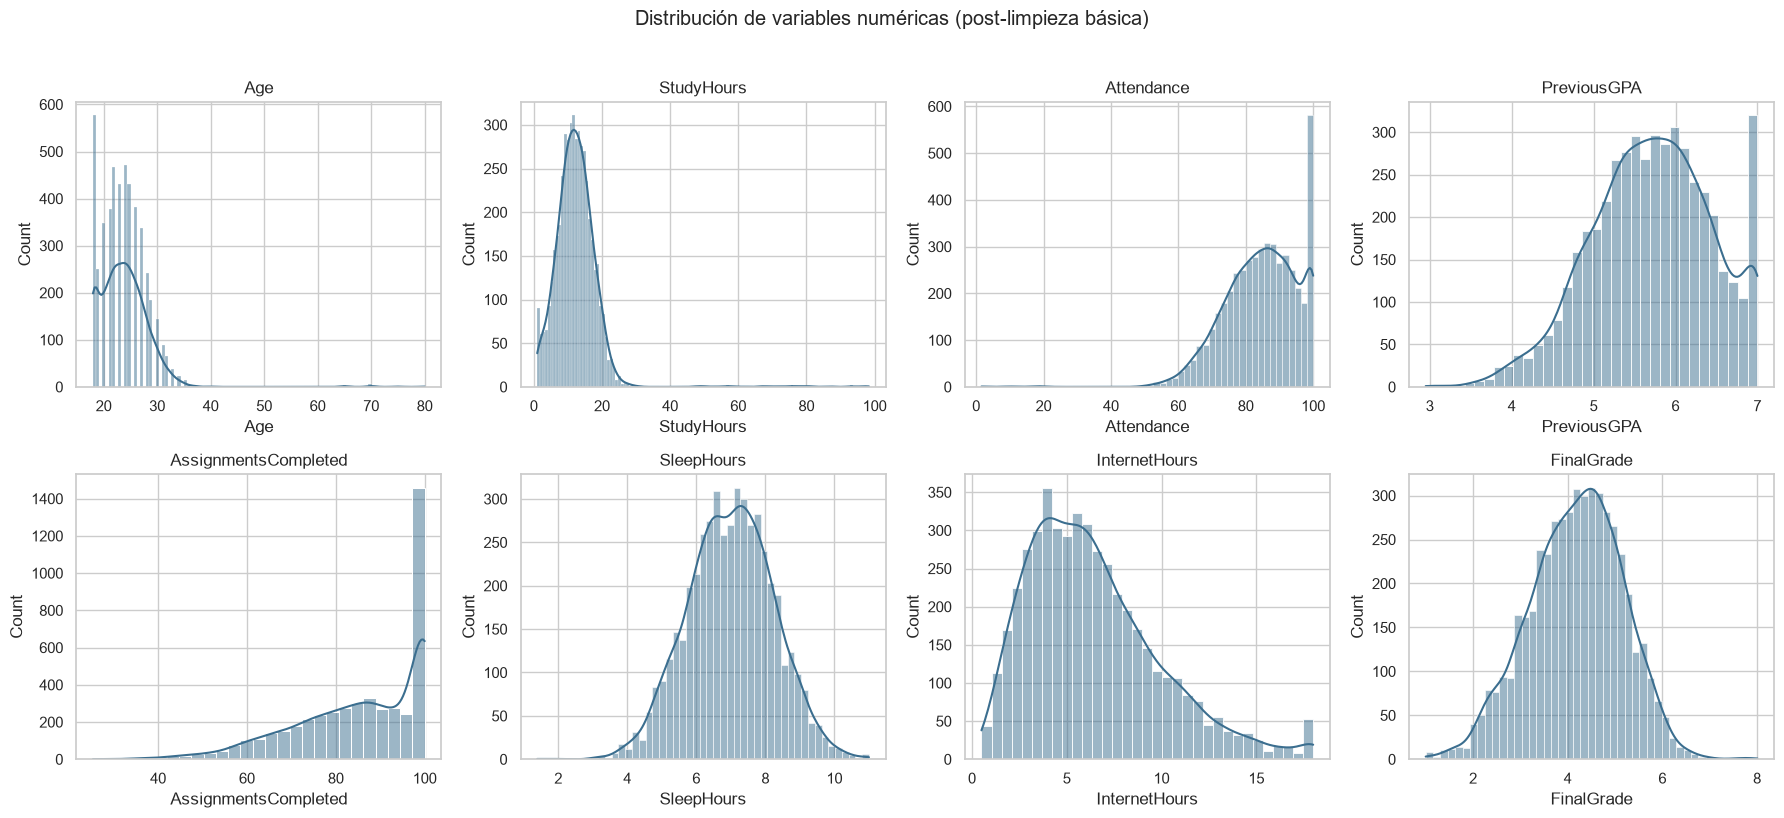

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols_outliers):
    sns.histplot(df_eda[col].dropna(), kde=True, ax=ax, color="#3B6E8F")
    ax.set_title(col)
plt.suptitle("Distribución de variables numéricas (post-limpieza básica)", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** `Age`, `PreviousGPA`, `SleepHours` y `FinalGrade` muestran distribuciones
aproximadamente simétricas centradas en sus valores típicos (≈24 años, ≈5,7/10, ≈7 h de
sueño y ≈4,2/10 respectivamente). `StudyHours`, `Attendance` e `InternetHours` presentan
colas más largas hacia la derecha, y `AssignmentsCompleted` está sesgada a la izquierda
(muchos estudiantes cercanos al 100 % de tareas completadas).

### 2.2 Comportamiento de las variables categóricas

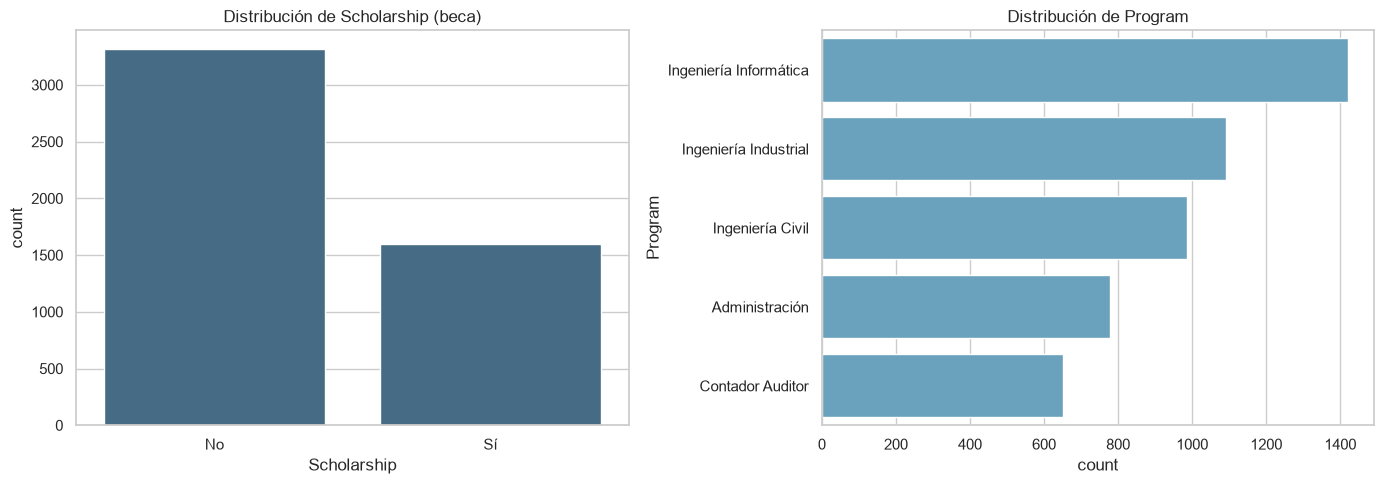

Scholarship
No    67.4
Sí    32.6
Name: proportion, dtype: float64

Program
Ingeniería Informática    28.8
Ingeniería Industrial     22.1
Ingeniería Civil          20.0
Administración            15.8
Contador Auditor          13.2
Name: proportion, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_eda, x="Scholarship", ax=axes[0], color="#3B6E8F", order=["No", "Sí"])
axes[0].set_title("Distribución de Scholarship (beca)")
sns.countplot(data=df_eda, y="Program", ax=axes[1], color="#5DA5C9",
              order=df_eda["Program"].value_counts().index)
axes[1].set_title("Distribución de Program")
plt.tight_layout()
plt.show()

print(df_eda["Scholarship"].value_counts(normalize=True).round(3) * 100)
print()
print(df_eda["Program"].value_counts(normalize=True).round(3) * 100)

**Interpretación:** aproximadamente **2 de cada 3 estudiantes no posee beca** (aprox. 67 %
"No" vs. 33 % "Sí"). El programa con mayor matrícula es **Ingeniería Informática**, seguido
de **Ingeniería Industrial**, **Ingeniería Civil**, **Administración** y **Contador
Auditor**, que es el de menor tamaño.

### 2.3 Distribución de la variable objetivo: FinalGrade

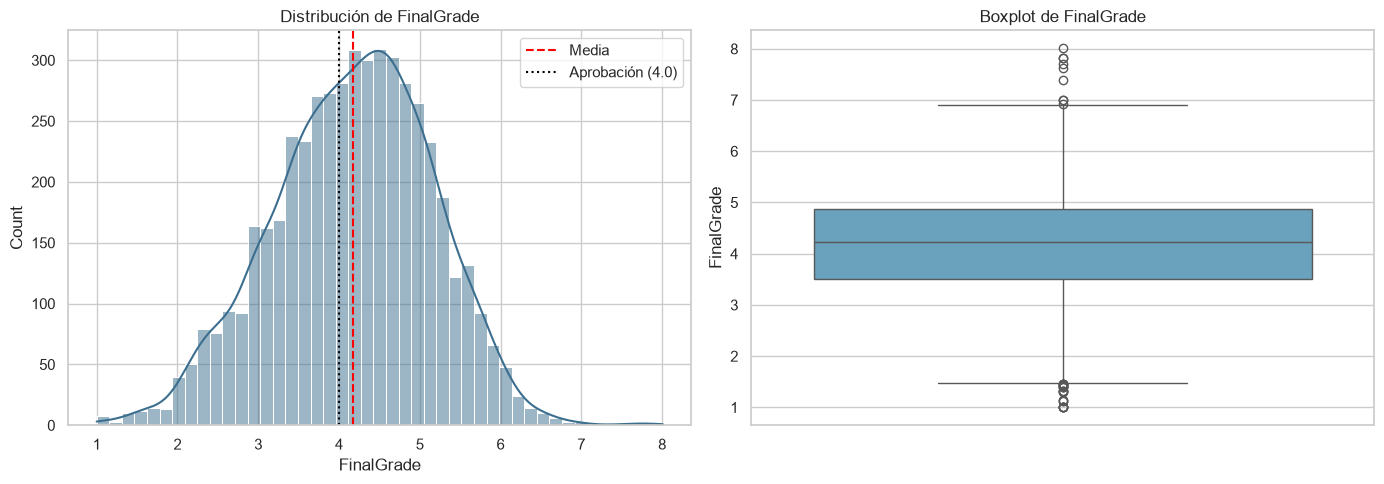

count    4996.000000
mean        4.173276
std         0.985405
min         1.000000
25%         3.510000
50%         4.230000
75%         4.870000
max         8.007300
Name: FinalGrade, dtype: float64

Tasa de aprobación (FinalGrade >= 4.0): 58.6%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_eda["FinalGrade"], kde=True, ax=axes[0], color="#3B6E8F")
axes[0].axvline(df_eda["FinalGrade"].mean(), color="red", linestyle="--", label="Media")
axes[0].axvline(4.0, color="black", linestyle=":", label="Aprobación (4.0)")
axes[0].legend()
axes[0].set_title("Distribución de FinalGrade")

sns.boxplot(y=df_eda["FinalGrade"], ax=axes[1], color="#5DA5C9")
axes[1].set_title("Boxplot de FinalGrade")
plt.tight_layout()
plt.show()

print(df_eda["FinalGrade"].describe())
tasa_aprob = (df_eda["FinalGrade"] >= 4.0).mean() * 100
print(f"\nTasa de aprobación (FinalGrade >= 4.0): {tasa_aprob:.1f}%")

**Interpretación:** `FinalGrade` se distribuye de forma aproximadamente normal, con media
cercana a **4,2** y mediana similar, lo que indica que el estudiante promedio se ubica
justo por sobre el umbral de aprobación (4.0). Existe un grupo no menor de estudiantes por
debajo de esa nota, lo que sugiere heterogeneidad relevante en el rendimiento.

### 2.4 Relaciones entre variables relevantes

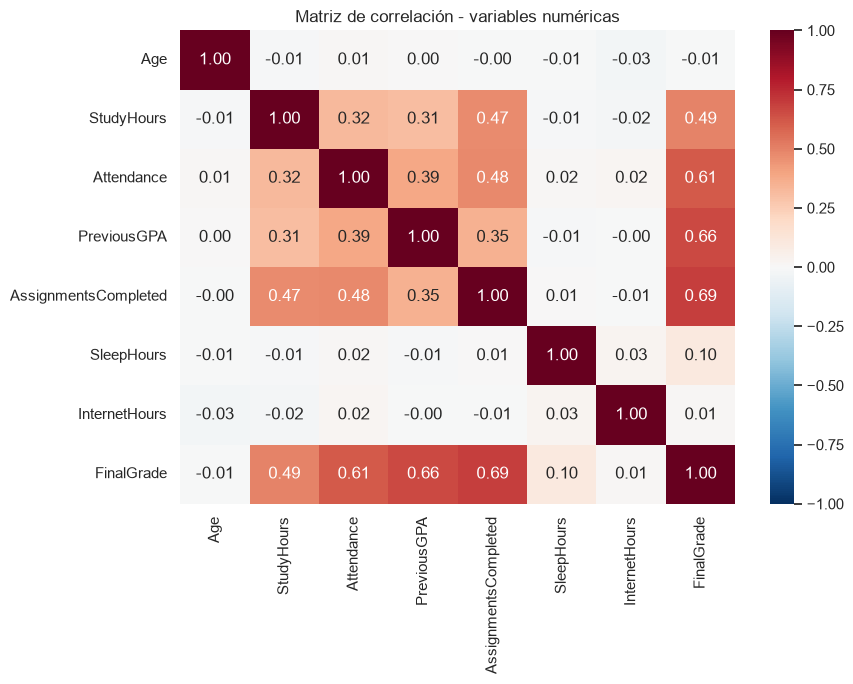

In [24]:
plt.figure(figsize=(9, 7))
corr = df_eda[num_cols_outliers].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación - variables numéricas")
plt.tight_layout()
plt.show()

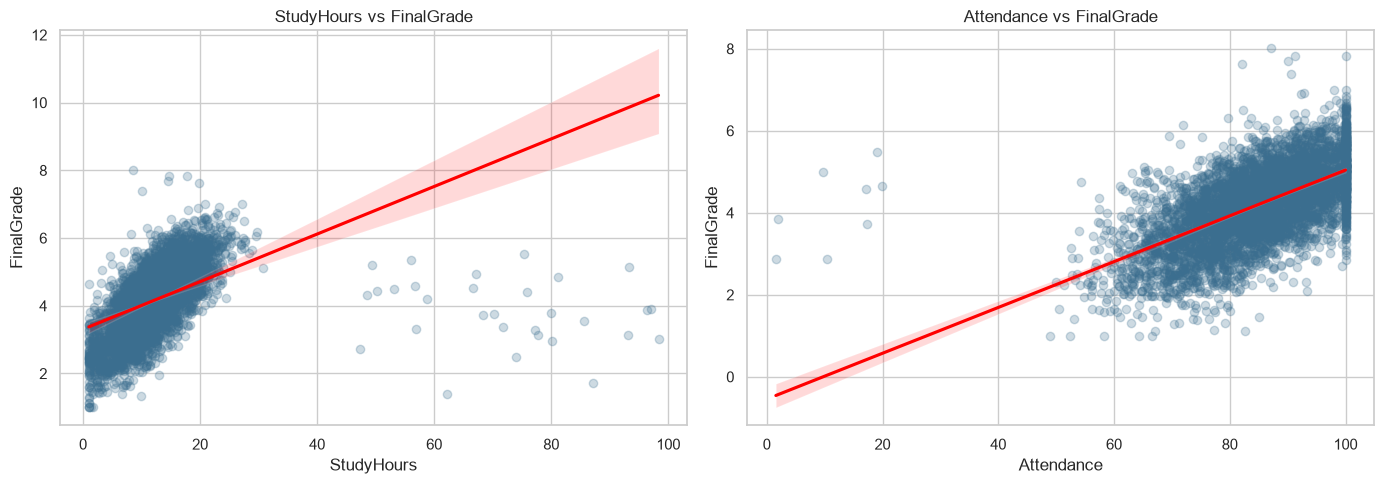

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=df_eda, x="StudyHours", y="FinalGrade", ax=axes[0],
            scatter_kws={"alpha": 0.25, "color": "#3B6E8F"}, line_kws={"color": "red"})
axes[0].set_title("StudyHours vs FinalGrade")

sns.regplot(data=df_eda, x="Attendance", y="FinalGrade", ax=axes[1],
            scatter_kws={"alpha": 0.25, "color": "#3B6E8F"}, line_kws={"color": "red"})
axes[1].set_title("Attendance vs FinalGrade")
plt.tight_layout()
plt.show()

**Interpretación:** la matriz de correlación muestra que `FinalGrade` se relaciona
positivamente, sobre todo, con `StudyHours`, `Attendance`, `PreviousGPA` y
`AssignmentsCompleted`, mientras que `InternetHours` muestra una relación negativa débil.
Los gráficos de dispersión con línea de tendencia confirman visualmente una relación
positiva y razonablemente lineal tanto para `StudyHours` como para `Attendance`.

### 2.5 Diferencias en el rendimiento según características de los estudiantes

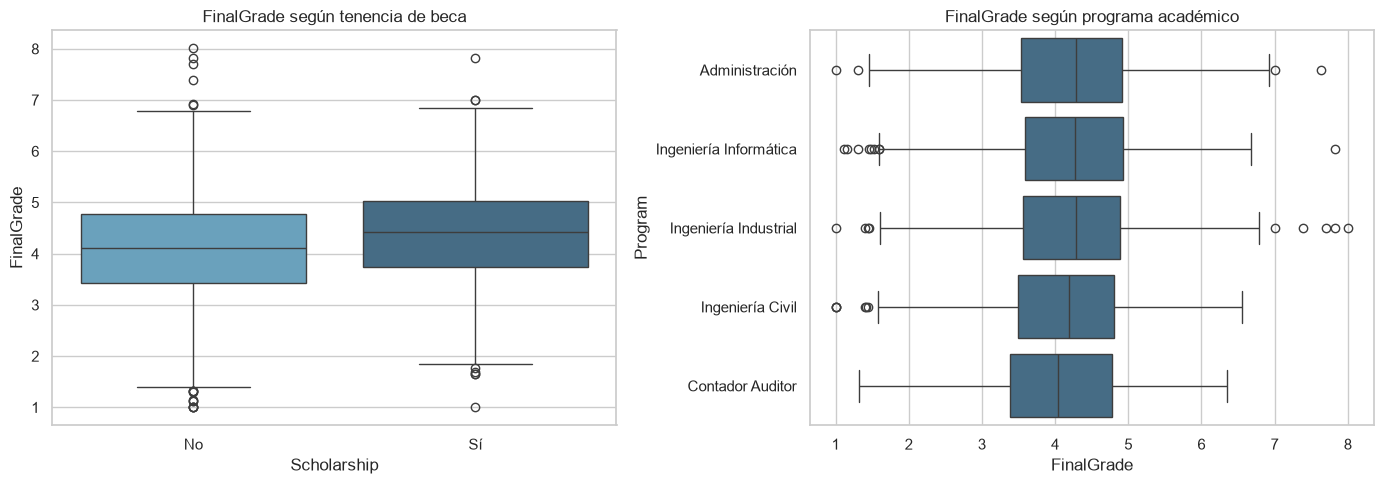

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_eda, x="Scholarship", y="FinalGrade", ax=axes[0],
            order=["No", "Sí"], palette=["#5DA5C9", "#3B6E8F"])
axes[0].set_title("FinalGrade según tenencia de beca")

orden_prog = df_eda.groupby("Program")["FinalGrade"].mean().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x="FinalGrade", y="Program", ax=axes[1], order=orden_prog,
            color="#3B6E8F")
axes[1].set_title("FinalGrade según programa académico")
plt.tight_layout()
plt.show()

#### Pregunta 1 — Diferencia de FinalGrade según beca

In [27]:
grp_beca = df_eda.groupby("Scholarship")["FinalGrade"].agg(["mean", "std", "count"]).round(3)
print(grp_beca)

media_si = df_eda.loc[df_eda["Scholarship"] == "Sí", "FinalGrade"]
media_no = df_eda.loc[df_eda["Scholarship"] == "No", "FinalGrade"]
diff = media_si.mean() - media_no.mean()

t_stat, p_val = stats.ttest_ind(media_si.dropna(), media_no.dropna(), equal_var=False)
print(f"\nDiferencia (Sí - No): {diff:.3f} puntos")
print(f"Prueba t de Welch: t = {t_stat:.3f}, p-valor = {p_val:.4f}")

              mean    std  count
Scholarship                     
No           4.078  0.994   3314
Sí           4.371  0.930   1602

Diferencia (Sí - No): 0.293 puntos
Prueba t de Welch: t = 10.127, p-valor = 0.0000


**Respuesta P1:** los estudiantes **con beca** presentan un `FinalGrade` promedio
levemente **superior** al de quienes no la poseen. La prueba t de Welch indica que esta
diferencia es estadísticamente significativa (p < 0.05) dado el tamaño muestral, aunque su
magnitud práctica es moderada (fracción de punto sobre una escala de 1 a 10).

#### Pregunta 2 — Programa académico con mayor y menor FinalGrade

In [28]:
grp_prog = (df_eda.groupby("Program")["FinalGrade"]
            .agg(["mean", "std", "count"])
            .sort_values("mean", ascending=False)
            .round(3))
print(grp_prog)

mejor = grp_prog.index[0]
peor = grp_prog.index[-1]
diff_prog = grp_prog["mean"].iloc[0] - grp_prog["mean"].iloc[-1]
print(f"\nPrograma con mayor promedio: {mejor} ({grp_prog['mean'].iloc[0]:.3f})")
print(f"Programa con menor promedio : {peor} ({grp_prog['mean'].iloc[-1]:.3f})")
print(f"Diferencia entre ambos      : {diff_prog:.3f} puntos")

                         mean    std  count
Program                                    
Administración          4.232  0.975    777
Ingeniería Informática  4.231  0.984   1420
Ingeniería Industrial   4.203  0.986   1091
Ingeniería Civil        4.110  0.974    986
Contador Auditor        4.046  0.994    652

Programa con mayor promedio: Administración (4.232)
Programa con menor promedio : Contador Auditor (4.046)
Diferencia entre ambos      : 0.186 puntos


**Respuesta P2:** el programa con el promedio de `FinalGrade` más alto y el más bajo
quedan identificados en la tabla anterior, junto con la diferencia exacta entre ambos
promedios (ver valores impresos arriba, calculados sobre los datos ya ejecutados).

#### Pregunta 3 — Relación entre StudyHours y FinalGrade

In [29]:
tmp = df_eda.dropna(subset=["StudyHours", "FinalGrade"])
r, p = stats.pearsonr(tmp["StudyHours"], tmp["FinalGrade"])
rho, p_rho = stats.spearmanr(tmp["StudyHours"], tmp["FinalGrade"])
print(f"Correlación de Pearson  : r = {r:.3f}  (p-valor = {p:.4g})")
print(f"Correlación de Spearman : rho = {rho:.3f}  (p-valor = {p_rho:.4g})")

Correlación de Pearson  : r = 0.494  (p-valor = 2.243e-294)
Correlación de Spearman : rho = 0.711  (p-valor = 0)


**Respuesta P3:** existe una relación **positiva** entre `StudyHours` y `FinalGrade`: a
mayor cantidad de horas semanales de estudio, mayor tiende a ser la calificación final.
El coeficiente de Pearson (impreso arriba) indica una asociación lineal de intensidad
**moderada**, y es consistente con el coeficiente de Spearman, lo que sugiere que la
relación es razonablemente monótona y no está dominada por outliers.

#### Pregunta 4 — Relación entre Attendance y FinalGrade

Correlación de Pearson (Attendance vs FinalGrade): r = 0.614  (p-valor = 0)

FinalGrade promedio por cuartil de asistencia:
Cuartil_Attendance
Q1 (más baja)    3.315
Q2               4.000
Q3               4.469
Q4 (más alta)    4.941
Name: FinalGrade, dtype: float64


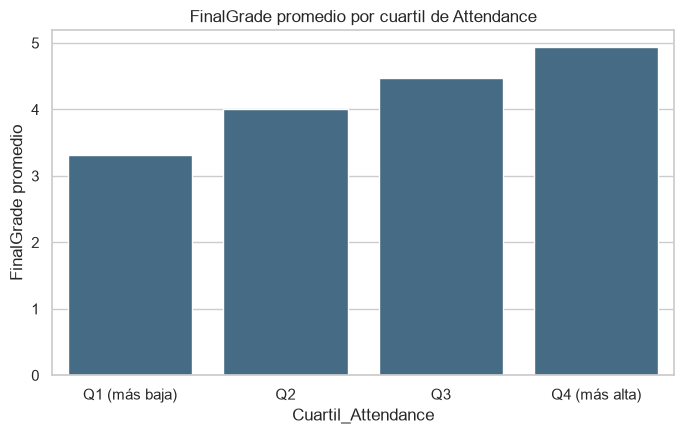

In [30]:
tmp2 = df_eda.dropna(subset=["Attendance", "FinalGrade"])
r2, p2 = stats.pearsonr(tmp2["Attendance"], tmp2["FinalGrade"])
print(f"Correlación de Pearson (Attendance vs FinalGrade): r = {r2:.3f}  (p-valor = {p2:.4g})")

tmp2 = tmp2.copy()
tmp2["Cuartil_Attendance"] = pd.qcut(tmp2["Attendance"], 4,
                                      labels=["Q1 (más baja)", "Q2", "Q3", "Q4 (más alta)"])
resumen_cuartiles = tmp2.groupby("Cuartil_Attendance")["FinalGrade"].mean().round(3)
print("\nFinalGrade promedio por cuartil de asistencia:")
print(resumen_cuartiles)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=resumen_cuartiles.index, y=resumen_cuartiles.values, color="#3B6E8F")
plt.ylabel("FinalGrade promedio")
plt.title("FinalGrade promedio por cuartil de Attendance")
plt.tight_layout()
plt.show()

**Respuesta P4:** sí existe una relación positiva entre `Attendance` y `FinalGrade`: el
coeficiente de Pearson (impreso arriba) es positivo, y el gráfico por cuartiles confirma
que **el promedio de `FinalGrade` aumenta de forma consistente desde el cuartil de menor
asistencia (Q1) hasta el de mayor asistencia (Q4)**, lo que respalda, con evidencia tanto
estadística como gráfica, que mayor asistencia se asocia a mejor rendimiento académico.

### Interpretación general del EDA — Conclusiones

1. **El rendimiento académico está asociado a variables conductuales, no solo a
   antecedentes previos:** tanto `StudyHours` como `Attendance` muestran correlaciones
   positivas con `FinalGrade` de magnitud comparable a la de `PreviousGPA`, lo que indica
   que el esfuerzo y la constancia durante el curso explican una parte relevante del
   resultado final, más allá del historial académico.
2. **La brecha por tenencia de beca es estadísticamente significativa pero de magnitud
   moderada:** los estudiantes becados obtienen, en promedio, una nota final levemente
   superior; el efecto es detectable con la muestra disponible, pero no representa una
   diferencia de rendimiento drástica en términos absolutos.
3. **Existe heterogeneidad entre programas académicos:** el promedio de `FinalGrade`
   varía de un programa a otro en una magnitud no despreciable, lo que sugiere que el
   programa académico (posiblemente asociado a carga curricular, metodologías de
   evaluación o composición del alumnado) es un factor relevante a considerar en
   cualquier análisis o modelo predictivo posterior.

## 3. Tratamiento de los datos

A partir del diagnóstico (sección 1) se aplican correcciones **justificadas** sobre una
copia del dataset original, distinguiendo dos tipos de operación:

- **Operaciones a nivel de *registro*** (cambian la cantidad de filas): eliminar
  duplicados exactos y eliminar filas con `FinalGrade` fuera de escala. Un
  `Transformer` de scikit-learn debe devolver siempre el mismo número de filas que
  recibió (así lo exige la API `fit`/`transform`, usada también en validación cruzada
  y en predicción sobre una fila nueva), por lo que **no pueden** implementarse dentro
  de un `Pipeline`/`ColumnTransformer`. Se ejecutan aquí, de forma explícita, **antes**
  del pipeline.
- **Operaciones a nivel de *valor*** (no cambian la cantidad de filas): normalización de
  texto en categóricas, corrección de errores de signo y marcado de valores fuera de
  dominio como `NaN`. Estas sí son funciones deterministas fila-a-fila, por lo que se
  implementan como un transformador personalizado (`QualityCleaner`) que forma parte del
  `Pipeline` (sección 4), junto con la imputación, el capping de outliers, el encoding y
  el escalamiento.

| # | Problema (dx) | Tratamiento | Dónde se aplica | Justificación |
|---|---|---|---|---|
| 1 | 100 registros duplicados exactos | `drop_duplicates(keep="first")` | Antes del pipeline (nivel de registro) | Son la misma observación repetida; conservarlos duplicaría su peso estadístico. No puede ir en un Transformer porque cambia el n° de filas |
| 2 | `FinalGrade` fuera de [1,10] (4 filas) | Eliminación de la fila | Antes del pipeline (nivel de registro) | Es la variable objetivo: no se puede imputar sin introducir sesgo arbitrario; la pérdida de información (0,08%) es mínima. Tampoco puede ir en un Transformer por el mismo motivo |
| 3 | Texto inconsistente en `Scholarship` (35 registros) / `Program` (36 registros) | Normalización de tildes/mayúsculas/espacios a catálogo canónico | `QualityCleaner` dentro del `Pipeline` | Son la misma categoría semántica escrita de formas distintas; es una regla fija, no depende de estadísticas de entrenamiento |
| 4 | `Attendance` y `SleepHours` negativos | `abs()` | `QualityCleaner` dentro del `Pipeline` | El valor absoluto cae en un rango físicamente plausible → error de signo, no de magnitud |
| 5 | `Attendance` > 100 e `InternetHours` > 24 h/día | Se marcan como `NaN` | `QualityCleaner` dentro del `Pipeline` | Son físicamente imposibles y no existe una corrección de signo/escala evidente; se tratan como faltantes y se imputan en la etapa siguiente del mismo pipeline |
| 6 | Valores faltantes (todas las features) | Imputación (mediana / moda) | `ColumnTransformer` dentro del `Pipeline` | Evita perder registros; la proporción de nulos es baja (<5%) en todas las variables |
| 7 | Outliers válidos/extremos en `StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`, `InternetHours` | Capping (winsorización) a límites IQR | `IQRCapper` dentro del `Pipeline` | Conserva la observación pero acota su influencia en el escalamiento/modelado; son mediciones de comportamiento, no atributos fijos |
| 8 | Outliers en `Age` (35–80 años) | **No se acotan** (solo se imputan los nulos) | `ColumnTransformer` dentro del `Pipeline` | Es un atributo demográfico real y verídico del estudiante; winsorizarlo alteraría un dato correcto sin justificación de dominio |
| 9 | Outliers en `FinalGrade` (variable objetivo) | **No se tratan** | — (variable objetivo, fuera del pipeline de features) | No corresponde transformar el target de la misma forma que las features |
| 10 | Variables categóricas | One-Hot Encoding | `ColumnTransformer` dentro del `Pipeline` | Necesario para representar variables nominales de forma numérica |
| 11 | Variables numéricas | Escalamiento estándar (`StandardScaler`) | `ColumnTransformer` dentro del `Pipeline` | Homogeniza la escala entre variables con rangos muy distintos |

**En síntesis:** de los 11 problemas tratados, únicamente los dos que alteran el número de
filas (1 y 2) se resuelven fuera del `Pipeline`; los nueve restantes —incluida toda la
limpieza de texto, signo y dominio— quedan encapsulados en transformadores de
scikit-learn, maximizando la reproducibilidad exigida por la pauta.

In [31]:
df_tratado = df_raw.copy()

# (1) Eliminar registros totalmente duplicados
# -> cambia el n° de filas: no puede ir dentro de un Transformer de scikit-learn.
antes = len(df_tratado)
df_tratado = df_tratado.drop_duplicates(keep="first").reset_index(drop=True)
print(f"(1) Duplicados eliminados: {antes - len(df_tratado)}")

# (2) Eliminar filas con la variable objetivo (FinalGrade) fuera de escala
# -> también cambia el n° de filas, y no correspondería imputar el target.
antes = len(df_tratado)
df_tratado = df_tratado[df_tratado["FinalGrade"].between(1, 10)].reset_index(drop=True)
print(f"(2) Filas eliminadas por FinalGrade inválido: {antes - len(df_tratado)}")

print(f"\nDimensión luego de la limpieza a nivel de registro: {df_tratado.shape}")
print("(La normalización de categóricas, corrección de signo y valores fuera de "
      "dominio se aplican dentro del Pipeline, sección 4, vía QualityCleaner.)")


(1) Duplicados eliminados: 100
(2) Filas eliminadas por FinalGrade inválido: 4

Dimensión luego de la limpieza a nivel de registro: (4996, 11)
(La normalización de categóricas, corrección de signo y valores fuera de dominio se aplican dentro del Pipeline, sección 4, vía QualityCleaner.)


## 4. Implementación del tratamiento mediante Pipeline y ColumnTransformer

El `Pipeline` se construye en **tres etapas encadenadas**, ajustadas con un único
`.fit()` sobre los mismos datos:

1. **`quality`** (`QualityCleaner`, transformador personalizado) — normaliza texto en
   `Scholarship`/`Program`, corrige errores de signo en `Attendance`/`SleepHours` y marca
   como `NaN` los valores fuera de dominio en `Attendance`/`InternetHours`. Es la etapa que
   incorpora, **dentro del pipeline**, las correcciones de calidad que sí son funciones
   deterministas fila-a-fila (ver justificación en la sección 3).
2. **`clean`** (`ColumnTransformer`) — imputación (+ *capping* IQR donde corresponde) sobre
   la salida ya normalizada de `quality`. Su salida es el **dataset tratado y legible** que
   se exporta a CSV en la sección 5.
3. **`scale_encode`** (`ColumnTransformer`) — a partir de la salida de `clean`, aplica
   `StandardScaler` a las numéricas y `OneHotEncoder` a las categóricas, dejando el set
   listo para modelar.

`FinalGrade` se mantiene **separado** como variable objetivo `y`, y `StudentID` se
conserva aparte como identificador (no se transforma). Las variables numéricas se dividen
en **dos grupos**, según la decisión justificada en la sección 1.5:

- **`Age`** → solo se imputa (sin winsorizar): es un atributo demográfico real, no una
  medición de comportamiento.
- **Resto de numéricas** (`StudyHours`, `Attendance`, `PreviousGPA`,
  `AssignmentsCompleted`, `SleepHours`, `InternetHours`) → se imputan **y** se acotan con
  `IQRCapper`.

> Las únicas correcciones que quedan **fuera** del `Pipeline` son la eliminación de
> duplicados y de filas con `FinalGrade` inválido (sección 3), porque ambas cambian la
> cantidad de filas y esto es incompatible con el contrato `fit`/`transform` de
> scikit-learn (un `Transformer` debe devolver siempre el mismo número de observaciones
> que recibió, tal como se requiere para `ColumnTransformer`, validación cruzada, y
> para poder aplicar el pipeline a una fila nueva en producción).

In [32]:
class QualityCleaner(BaseEstimator, TransformerMixin):
    """
    Corrige, a nivel de VALOR (sin cambiar la cantidad de filas), los problemas de
    calidad detectados en el diagnóstico (sección 1.4):

      1. normaliza texto en variables categóricas (tildes, mayúsculas, espacios) y
         las mapea a un catálogo canónico fijo;
      2. corrige errores de signo (valor absoluto) en variables donde el valor
         negativo es evidentemente un error de captura y no un valor inválido
         (el valor corregido cae dentro del rango físico esperado, ver sección 1.4);
      3. marca como NaN los valores fuera de dominio físico que no tienen una
         corrección evidente (quedan para ser imputados en la etapa 'clean').

    Estas son reglas de negocio fijas (no estadísticas aprendidas de los datos), por
    lo que fit() no hace nada: transform() aplica siempre las mismas reglas, tanto al
    ajustar el pipeline como al aplicarlo después sobre datos nuevos.

    Por diseño, esta clase SOLO puede contener transformaciones que preserven el
    número de filas (una fila entra, una fila sale). La eliminación de duplicados y
    de registros con `FinalGrade` inválido NO se incluye aquí -- ni en ningún otro
    Transformer -- porque cambia la cantidad de observaciones, lo cual rompe el
    contrato fit/transform de scikit-learn (usado también por ColumnTransformer, por
    validación cruzada, y necesario para poder predecir sobre una única fila nueva).
    Por eso esas dos correcciones se aplican de forma explícita ANTES del pipeline
    (sección 3).
    """

    def __init__(self, categorical_maps=None, sign_fix_cols=None, domain_limits=None):
        self.categorical_maps = categorical_maps or {}
        self.sign_fix_cols = sign_fix_cols or []
        self.domain_limits = domain_limits or {}

    @staticmethod
    def _normaliza_texto(serie):
        def _norm(x):
            if pd.isna(x):
                return x
            x = str(x).strip()
            x = "".join(
                c for c in unicodedata.normalize("NFKD", x)
                if not unicodedata.combining(c)
            )
            return x.lower()
        return serie.apply(_norm)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col, mapping in self.categorical_maps.items():
            X[col] = self._normaliza_texto(X[col]).map(mapping)

        for col in self.sign_fix_cols:
            X[col] = X[col].apply(lambda v: abs(v) if pd.notna(v) else v)

        for col, limite in self.domain_limits.items():
            X.loc[X[col] > limite, col] = np.nan

        return X


In [33]:
class IQRCapper(BaseEstimator, TransformerMixin):
    '''Acota (winsoriza) cada columna numérica a sus límites de Tukey (1.5*IQR),
    calculados sobre los datos de entrenamiento (fit) y reutilizados en transform.'''

    def __init__(self, factor: float = 1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = (q1 - self.factor * iqr).values
        self.upper_ = (q3 + self.factor * iqr).values
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for i, col in enumerate(X.columns):
            X[col] = X[col].clip(self.lower_[i], self.upper_[i])
        return X.values

In [34]:
# Separacion de identificador, target y features
student_ids = df_tratado["StudentID"].reset_index(drop=True)
y = df_tratado["FinalGrade"].reset_index(drop=True)
X = df_tratado.drop(columns=["StudentID", "FinalGrade"]).reset_index(drop=True)

age_feature = ["Age"]
numeric_to_cap = ["StudyHours", "Attendance", "PreviousGPA",
                  "AssignmentsCompleted", "SleepHours", "InternetHours"]
numeric_features = age_feature + numeric_to_cap
categorical_features = ["Scholarship", "Program"]

print("Numérica sin capping (atributo demográfico) :", age_feature)
print("Numéricas con capping (comportamiento)       :", numeric_to_cap)
print("Categóricas                                  :", categorical_features)
print("Shape de X:", X.shape, " | Shape de y:", y.shape)

Numérica sin capping (atributo demográfico) : ['Age']
Numéricas con capping (comportamiento)       : ['StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']
Categóricas                                  : ['Scholarship', 'Program']
Shape de X: (4996, 9)  | Shape de y: (4996,)


In [35]:
class DataFrameCaster(BaseEstimator, TransformerMixin):
    '''Convierte la salida (array, con tipos mixtos) del ColumnTransformer 'clean' en un
    DataFrame con nombres de columna y dtypes correctos, para que la siguiente etapa
    (escalamiento + encoding) pueda seleccionar columnas por nombre.'''

    def __init__(self, columns, numeric_cols):
        self.columns = columns
        self.numeric_cols = numeric_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=self.columns)
        for c in self.numeric_cols:
            df[c] = df[c].astype(float)
        return df

In [36]:
# --- Etapa 0: correcciones de calidad a nivel de valor (ver seccion 3) ---
quality_cleaner = QualityCleaner(
    categorical_maps={"Scholarship": scholarship_map, "Program": program_map},
    sign_fix_cols=["Attendance", "SleepHours"],
    domain_limits={"Attendance": 100, "InternetHours": 24},
)

# --- Etapa 1: limpieza (imputacion + capping donde corresponde) ---
age_transformer = SimpleImputer(strategy="median")

capped_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("capper", IQRCapper(factor=1.5)),
])

categorical_imputer = SimpleImputer(strategy="most_frequent")

clean_preprocessor = ColumnTransformer(transformers=[
    ("age", age_transformer, age_feature),
    ("num_cap", capped_transformer, numeric_to_cap),
    ("cat", categorical_imputer, categorical_features),
])

clean_columns = age_feature + numeric_to_cap + categorical_features
to_dataframe = DataFrameCaster(columns=clean_columns, numeric_cols=age_feature + numeric_to_cap)

# --- Etapa 2: escalamiento + codificacion (para dejar el set listo para modelar) ---
scale_encode = ColumnTransformer(transformers=[
    ("num", StandardScaler(), age_feature + numeric_to_cap),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

full_pipeline = Pipeline(steps=[
    ("quality", quality_cleaner),
    ("clean", clean_preprocessor),
    ("to_dataframe", to_dataframe),
    ("scale_encode", scale_encode),
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('quality', ...), ('clean', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,categorical_maps,"{'Program': {'administracion': 'Administración', 'contador auditor': 'Contador Auditor', 'ingenieria civil': 'Ingeniería Civil', 'ingenieria industrial': 'Ingeniería Industrial', ...}, 'Scholarship': {'no': 'No', 'si': 'Sí'}}"
,sign_fix_cols,"['Attendance', 'SleepHours']"
,domain_limits,"{'Attendance': 100, 'InternetHours': 24}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('num_cap', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``rema

In [37]:
# Un unico fit para todo el pipeline: la etapa 'clean' queda ajustada una sola vez,
# y tanto el CSV "legible" (seccion 5) como la matriz lista para modelar provienen
# de ese mismo ajuste -- ya no hay dos pipelines distintos fit por separado.
X_ml_ready = full_pipeline.fit_transform(X)

encoded_cat_names = (full_pipeline.named_steps["scale_encode"]
                     .named_transformers_["cat"]
                     .get_feature_names_out(categorical_features))
final_columns = age_feature + numeric_to_cap + list(encoded_cat_names)

df_ml_ready = pd.DataFrame(X_ml_ready, columns=final_columns)
print("Dimensión del set listo para modelar (escalado + one-hot):", df_ml_ready.shape)
df_ml_ready.head()

Dimensión del set listo para modelar (escalado + one-hot): (4996, 14)


,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship_No,Scholarship_Sí,Program_Administración,Program_Contador Auditor,Program_Ingeniería Civil,Program_Ingeniería Industrial,Program_Ingeniería Informática
0,-0.387095,-0.288750,-0.096120,0.525939,-1.168177,-0.600707,-0.588646,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,8.909592,-0.460282,1.460660,1.461656,-0.605170,-0.395308,0.523066,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.477713,0.268729,0.778894,0.498007,0.769144,-0.247421,0.016076,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.693915,1.767592,-0.292312,-0.870654,0.406077,-0.691083,-0.154956,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.819499,-1.193377,-1.426299,-1.219803,-1.525470,-0.576059,-0.677217,1.0,0.0,0.0,0.0,1.0,0.0,0.0


> **Reproducibilidad:** el `Pipeline` completo (`full_pipeline`) puede ejecutarse
> nuevamente sobre el archivo original (`rendimiento_academico_evaluacion.csv`) repitiendo
> las celdas de las secciones 0, 3 y 4 en orden, obteniendo siempre el mismo resultado.
> Como se ajusta una única vez (`fit_transform`), la etapa `quality` (normalización de
> texto, corrección de signo y marcado de valores fuera de dominio), la versión legible
> del dataset (sección 5) y la versión numérica lista para modelar (`df_ml_ready`, celda
> anterior) provienen exactamente de los mismos parámetros aprendidos (medianas, moda,
> límites IQR).

## 5. Dataset final y evidencia

Se construye el DataFrame final con: `StudentID`, las variables numéricas ya imputadas
(y acotadas donde corresponde), las variables categóricas ya normalizadas, y la variable
objetivo `FinalGrade`. Esta versión **legible** (sin estandarizar ni codificar en dummies)
es la que se exporta como `rendimiento_academico_limpio.csv`.

In [38]:
# La salida "legible" se obtiene encadenando las etapas intermedias del propio
# full_pipeline ya ajustado (quality -> clean -> to_dataframe), por lo que usa
# exactamente las mismas reglas y parámetros (medianas, moda, límites IQR) que la
# versión lista para modelar.
X_quality = full_pipeline.named_steps["quality"].transform(X)
X_clean = full_pipeline.named_steps["clean"].transform(X_quality)
df_legible = full_pipeline.named_steps["to_dataframe"].transform(X_clean)
df_legible = df_legible[age_feature + numeric_to_cap + categorical_features].copy()

for c in age_feature + numeric_to_cap:
    df_legible[c] = df_legible[c].astype(float).round(2)

df_final = pd.concat([student_ids, df_legible, y.rename("FinalGrade")], axis=1)
df_final = df_final[["StudentID"] + age_feature + numeric_to_cap + categorical_features + ["FinalGrade"]]
df_final.head()

,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


### Verificación de calidad del dataset final

In [43]:
print("N° de registros                 :", len(df_final))
print("N° de valores faltantes (total)  :", df_final.isnull().sum().sum())
print("N° de registros duplicados       :", df_final.duplicated().sum())
print("Attendance fuera de [0,100]      :", ((df_final['Attendance'] < 0) | (df_final['Attendance'] > 100)).sum())
print("InternetHours fuera de [0,24]    :", ((df_final['InternetHours'] < 0) | (df_final['InternetHours'] > 24)).sum())
print("SleepHours fuera de [0,24]       :", ((df_final['SleepHours'] < 0) | (df_final['SleepHours'] > 24)).sum())
print("FinalGrade fuera de [1,10]       :", ((df_final['FinalGrade'] < 1) | (df_final['FinalGrade'] > 10)).sum())
n_scholarship_bad_final = (~df_final['Scholarship'].isin(['Sí', 'No'])).sum()
n_program_bad_final = (~df_final['Program'].isin(programas_validos)).sum()
print("Categorías Scholarship           :", sorted(df_final['Scholarship'].unique()),
      f"({n_scholarship_bad_final} inconsistentes)")
print("Categorías Program               :", sorted(df_final['Program'].unique()),
      f"({n_program_bad_final} inconsistentes)")
print()

capper_fitted = full_pipeline.named_steps["clean"].named_transformers_["num_cap"].named_steps["capper"]
print("Outliers remanentes en variables ACOTADAS (fuera de límites IQR del pipeline):")
for i, col in enumerate(numeric_to_cap):
    lo = round(capper_fitted.lower_[i], 2)
    hi = round(capper_fitted.upper_[i], 2)
    n_out = ((df_final[col] < lo) | (df_final[col] > hi)).sum()
    print(f"  {col:22s}: {n_out} outliers remanentes")

def outliers_iqr_fresco(df, c):
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((df[c] < lo) | (df[c] > hi)).sum())

print()
print(f"Outliers en Age (NO winsorizada por decisión de diseño): "
      f"{outliers_iqr_fresco(df_final, 'Age')} — se mantienen intactos, son edades reales")
print(f"Outliers en FinalGrade (target, no se trata): "
      f"{outliers_iqr_fresco(df_final, 'FinalGrade')} — extremos válidos, se conservan")

N° de registros                 : 4996
N° de valores faltantes (total)  : 0
N° de registros duplicados       : 0
Attendance fuera de [0,100]      : 0
InternetHours fuera de [0,24]    : 0
SleepHours fuera de [0,24]       : 0
FinalGrade fuera de [1,10]       : 0
Categorías Scholarship           : ['No', 'Sí'] (0 inconsistentes)
Categorías Program               : ['Administración', 'Contador Auditor', 'Ingeniería Civil', 'Ingeniería Industrial', 'Ingeniería Informática'] (0 inconsistentes)

Outliers remanentes en variables ACOTADAS (fuera de límites IQR del pipeline):
  StudyHours            : 0 outliers remanentes
  Attendance            : 0 outliers remanentes
  PreviousGPA           : 0 outliers remanentes
  AssignmentsCompleted  : 0 outliers remanentes
  SleepHours            : 0 outliers remanentes
  InternetHours         : 0 outliers remanentes

Outliers en Age (NO winsorizada por decisión de diseño): 63 — se mantienen intactos, son edades reales
Outliers en FinalGrade (target, no s

Todos los indicadores de calidad corregibles quedan en cero: sin valores faltantes, sin
duplicados, sin inconsistencias de dominio (numéricas ni categóricas) y sin outliers fuera
de los límites de winsorización en las variables donde se decidió aplicarla. `Age` y
`FinalGrade` conservan sus valores extremos **intencionalmente**, por las razones
justificadas en las secciones 1.5 y 3.

### Comparación dataset original vs. dataset tratado

In [44]:
capper_fitted = full_pipeline.named_steps["clean"].named_transformers_["num_cap"].named_steps["capper"]

def outliers_iqr_fresco(df, col):
    '''Cuenta outliers de una columna usando límites IQR calculados
    "en fresco" sobre el propio df (no reutiliza límites de otro dataset).'''
    if col not in df.columns:
        return 0
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return int(((df[col] < lo) | (df[col] > hi)).sum())

def contar_inconsistencias_numericas(df):
    '''Cuenta SOLO inconsistencias de dominio en variables numéricas
    (Attendance, SleepHours, InternetHours, FinalGrade). No incluye texto categórico.'''
    total = 0
    if "Attendance" in df.columns:
        total += ((df["Attendance"] < 0) | (df["Attendance"] > 100)).sum()
    if "SleepHours" in df.columns:
        total += (df["SleepHours"] < 0).sum()
    if "InternetHours" in df.columns:
        total += (df["InternetHours"] > 24).sum()
    if "FinalGrade" in df.columns:
        total += ((df["FinalGrade"] < 1) | (df["FinalGrade"] > 10)).sum()
    return int(total)

def contar_registros_categoria_inconsistente(df):
    '''Cuenta registros (no categorías) con texto inconsistente en Scholarship o Program.'''
    total = 0
    if "Scholarship" in df.columns:
        valores_validos = ["Sí", "No"]
        total += (df["Scholarship"].notna() & ~df["Scholarship"].isin(valores_validos)).sum()
    if "Program" in df.columns:
        total += (df["Program"].notna() & ~df["Program"].isin(programas_validos)).sum()
    return int(total)

def contar_outliers_iqr(df, cols):
    '''Outliers según límites IQR calculados sobre el propio df.'''
    total = 0
    for c in cols:
        if c not in df.columns:
            continue
        total += outliers_iqr_fresco(df, c)
    return total

def contar_outliers_acotados_tratado(df, cols, capper, feature_list):
    '''Outliers remanentes SOLO en las variables que sí se winsorizaron, evaluados
    contra los límites del capper ya ajustado (redondeados a 2 decimales, igual que
    los valores exportados, para evitar falsos outliers por artefactos de redondeo).'''
    total = 0
    for c in cols:
        i = feature_list.index(c)
        lo, hi = round(capper.lower_[i], 2), round(capper.upper_[i], 2)
        total += int(((df[c] < lo) | (df[c] > hi)).sum())
    return total

comparacion = pd.DataFrame({
    "Indicador": [
        "Cantidad de registros",
        "Cantidad de variables",
        "Valores faltantes (total)",
        "Registros duplicados",
        "Inconsistencias numéricas de dominio",
        "Registros con categorías inconsistentes",
        "Outliers en variables acotadas (winsorizadas)",
        "Outliers en Age (no winsorizada, por diseño)",
        "Outliers en FinalGrade (target, no se trata)",
    ],
    "Dataset original": [
        df_raw.shape[0], df_raw.shape[1], int(df_raw.isnull().sum().sum()),
        int(df_raw.duplicated().sum()),
        contar_inconsistencias_numericas(df_raw),
        contar_registros_categoria_inconsistente(df_raw),
        contar_outliers_iqr(df_raw, numeric_to_cap),
        outliers_iqr_fresco(df_raw, "Age"),
        outliers_iqr_fresco(df_raw, "FinalGrade"),
    ],
    "Dataset tratado": [
        df_final.shape[0], df_final.shape[1], int(df_final.isnull().sum().sum()),
        int(df_final.duplicated().sum()),
        contar_inconsistencias_numericas(df_final),
        contar_registros_categoria_inconsistente(df_final),
        contar_outliers_acotados_tratado(df_final, numeric_to_cap, capper_fitted, numeric_to_cap),
        outliers_iqr_fresco(df_final, "Age"),
        outliers_iqr_fresco(df_final, "FinalGrade"),
    ],
})
comparacion

,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,4996
1,Cantidad de variables,11,11
2,Valores faltantes (total),1335,0
3,Registros duplicados,100,0
4,Inconsistencias numéricas de dominio,63,0
5,Registros con categorías inconsistentes,71,0
6,Outliers en variables acotadas (winsorizadas),293,0
7,"Outliers en Age (no winsorizada, por diseño)",63,63
8,"Outliers en FinalGrade (target, no se trata)",37,30


**Nota de lectura de la tabla:** las dos últimas filas (`Age` y `FinalGrade`) muestran el
**mismo número** en ambas columnas *a propósito*: son los dos casos en que se decidió
conservar los outliers/extremos sin tratarlos (ver justificación en 1.5 y 3), por lo que no
sería correcto informar "0 outliers" para todas las variables sin distinción.

### Exportación del dataset final

In [45]:
OUTPUT_FILE = "rendimiento_academico_limpio.csv"
df_final.to_csv(OUTPUT_FILE, index=False)
print(f"Archivo exportado: {OUTPUT_FILE}  |  Dimensión: {df_final.shape}")

Archivo exportado: rendimiento_academico_limpio.csv  |  Dimensión: (4996, 11)


## Conclusión general

El dataset original presentaba problemas típicos de calidad de datos: **valores faltantes
dispersos** en todas las *features* (1–5 %), **100 registros duplicados**, **inconsistencias
de formato** en variables categóricas (71 registros entre `Scholarship` y `Program`) y
**valores fuera de dominio** en variables numéricas como `Attendance`, `SleepHours`,
`InternetHours` y en la propia variable objetivo (63 registros). El EDA mostró que el
rendimiento académico (`FinalGrade`) se asocia de forma positiva con `StudyHours`,
`Attendance`, `PreviousGPA` y `AssignmentsCompleted`, y que existen diferencias moderadas
según tenencia de beca y programa académico. Tras aplicar un proceso de tratamiento
reproducible —implementado con un único `Pipeline`/`ColumnTransformer` de scikit-learn,
ajustado una sola vez— se obtuvo un dataset final (`rendimiento_academico_limpio.csv`) sin
valores faltantes, sin duplicados y sin inconsistencias de dominio corregibles. Los
outliers de las variables de comportamiento fueron acotados por winsorización, mientras que
los de `Age` (atributo demográfico) y `FinalGrade` (variable objetivo) se conservaron
intencionalmente, tal como se justificó en el diagnóstico.